# Dissimilaridade comportamental (Double-Fault) entre EfficientNet b0–b7

Este notebook mede a **diversidade comportamental** entre os 8 modelos da familia
EfficientNet (`models/family-b0.pth` … `models/family-b7.pth`), ja treinados pelo
notebook `efficientnet-family-optuna-ordinal-focal.ipynb`, sobre o **conjunto de
validacao do PANDAS** (fold 3, mesmo filtro de entropia de 20% usado no treino).

**Double-Fault measure (DF).** Para um par de classificadores *(i, j)*:

$$DF_{ij} = \frac{N^{11}_{ij}}{N} = P(\text{ambos erram a mesma amostra})$$

onde `N` e o numero de amostras de validacao e `N^{11}` o numero de amostras
classificadas **incorretamente pelos dois** modelos. Valores **altos** indicam
modelos que *falham juntos* (comportamento redundante / pouca diversidade);
valores **baixos** indicam modelos que erram em amostras diferentes
(comportamento complementar / alta diversidade). A diagonal `DF_{ii}` e a propria
taxa de erro do modelo *i*.

**t-SNE.** A matriz DF (8×8) e convertida em uma matriz de **dissimilaridade**
(modelos que co-falham ficam *proximos*) e projetada em 2D com `t-SNE`
(`metric='precomputed'`) para visualizar o posicionamento de cada backbone.

> **Nota de compatibilidade.** Os checkpoints foram salvos por uma versao de
> `torch` >= 2.9 (formato com `.storage_alignment`). Caso o kernel use `torch`
> 2.8.x, o carregamento direto falha; este notebook inclui um leitor manual do
> zip do checkpoint que reconstroi o `state_dict` sem depender da versao do torch,
> e o re-salva em formato compativel (`models/family-<b>-t28.pth`).


In [21]:
import os
import sys
import gc
import io
import json
import zipfile
import pickle

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast
import torchvision.models as tvm

from sklearn.manifold import TSNE
from sklearn.metrics import cohen_kappa_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

sys.path.append('../..')
from utils.dataset import PandasOverlapDataset

In [22]:
SEED              = 42
OUTPUT_CLASSES    = 5        # limiares ordinais para ISUP 0-5
VAL_FOLD          = 3        # mesmo fold de validacao usado no treino
ENTROPY_DROP_FRAC = 0.20     # mesmo filtro de ruido usado no treino
NUM_WORKERS       = 4
USE_AMP           = True

REPO_DIR   = '../..'
DATA_DIR   = os.path.join(REPO_DIR, 'data')
IMAGES_DIR = os.path.join(REPO_DIR, '..', 'bag_of_patches')
MODEL_DIR  = 'models'
LOG_DIR    = 'logs'
os.makedirs(LOG_DIR, exist_ok=True)

MODELS_TO_RUN = ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7']

# batch de inferencia por backbone (nets maiores recebem batch menor p/ caber na VRAM)
BATCH_SIZE = {'b0': 8, 'b1': 8, 'b2': 8, 'b3': 4, 'b4': 4, 'b5': 2, 'b6': 2, 'b7': 2}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Device: {device}')
print(f'torch:  {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU:    {torch.cuda.get_device_name(0)}')

Device: cuda
torch:  2.8.0+cu128
GPU:    NVIDIA GeForce RTX 3060


## 1. Arquitetura e carregamento robusto dos pesos

Reconstruimos o wrapper `EfficientNetApi` do notebook de treino. Os checkpoints sao `state_dict`s puros; `dropout_rate`/`unfreeze_blocks` so afetam treino (nao a forma dos tensores), entao carregamos com valores padrao e `strict=True`.

`load_state_dict_any` tenta `torch.load`; se o checkpoint estiver no formato de torch >= 2.9 e o kernel for mais antigo, cai num leitor manual do zip.

In [23]:
EFFICIENTNET_REGISTRY = {
    'b0': (tvm.efficientnet_b0, tvm.EfficientNet_B0_Weights.DEFAULT),
    'b1': (tvm.efficientnet_b1, tvm.EfficientNet_B1_Weights.DEFAULT),
    'b2': (tvm.efficientnet_b2, tvm.EfficientNet_B2_Weights.DEFAULT),
    'b3': (tvm.efficientnet_b3, tvm.EfficientNet_B3_Weights.DEFAULT),
    'b4': (tvm.efficientnet_b4, tvm.EfficientNet_B4_Weights.DEFAULT),
    'b5': (tvm.efficientnet_b5, tvm.EfficientNet_B5_Weights.DEFAULT),
    'b6': (tvm.efficientnet_b6, tvm.EfficientNet_B6_Weights.DEFAULT),
    'b7': (tvm.efficientnet_b7, tvm.EfficientNet_B7_Weights.DEFAULT),
}


class EfficientNetApi(nn.Module):
    """Wrapper EfficientNet (b0-b7) com cabeca de regressao ordinal — identico ao treino."""

    def __init__(self, model, output_dimensions, dropout_rate=0.4, unfreeze_blocks=2):
        super().__init__()
        self.model = model

        for p in self.model.parameters():
            p.requires_grad = False
        if unfreeze_blocks > 0:
            for block in self.model.features[-unfreeze_blocks:]:
                for p in block.parameters():
                    p.requires_grad = True

        if isinstance(self.model.classifier, nn.Sequential):
            in_features = self.model.classifier[-1].in_features
        else:
            in_features = self.model.classifier.in_features
        self.model.classifier = nn.Identity()

        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, output_dimensions),
        )

    def extract(self, x):
        x = self.model(x)
        if x.ndim == 4:
            x = x.mean(dim=[2, 3])
        return x

    def forward(self, x):
        return self.head(self.extract(x))

In [24]:
# ── leitor manual do checkpoint (independente da versao do torch) ──────────────
_STORAGE_DTYPE = {
    torch.FloatStorage: np.float32,  torch.DoubleStorage: np.float64,
    torch.HalfStorage:  np.float16,  torch.LongStorage:   np.int64,
    torch.IntStorage:   np.int32,    torch.ShortStorage:  np.int16,
    torch.CharStorage:  np.int8,     torch.ByteStorage:   np.uint8,
    torch.BoolStorage:  np.bool_,
}


def _manual_load_state_dict(path):
    """Le um checkpoint .pth (zip) tensor-a-tensor, sem depender da versao do torch."""
    zf   = zipfile.ZipFile(path)
    root = zf.namelist()[0].split('/')[0]
    try:
        byteorder = zf.read(f'{root}/byteorder').decode().strip()
    except KeyError:
        byteorder = 'little'

    class _Ph:                       # placeholder de storage
        def __init__(self, dtype, key):
            self.dtype, self.key = dtype, key

    def _persistent_load(pid):
        assert pid[0] == 'storage', pid
        storage_type, key = pid[1], pid[2]
        return _Ph(_STORAGE_DTYPE[storage_type], str(key))

    def _rebuild(storage, storage_offset, size, stride, requires_grad=False, *rest):
        arr = np.frombuffer(zf.read(f'{root}/data/{storage.key}'), dtype=storage.dtype).copy()
        if byteorder == 'big':
            arr = arr.byteswap()
        return torch.as_strided(torch.from_numpy(arr), tuple(size), tuple(stride), storage_offset)

    class _Unpickler(pickle.Unpickler):
        def persistent_load(self, pid):
            return _persistent_load(pid)

        def find_class(self, module, name):
            if module == 'torch._utils' and name == '_rebuild_tensor_v2':
                return _rebuild
            return super().find_class(module, name)

    return _Unpickler(io.BytesIO(zf.read(f'{root}/data.pkl'))).load()


def load_state_dict_any(name):
    """Carrega o state_dict de family-<name>; usa cache -t28 ou converte se preciso."""
    t28  = os.path.join(MODEL_DIR, f'family-{name}-t28.pth')
    orig = os.path.join(MODEL_DIR, f'family-{name}.pth')
    if os.path.exists(t28):
        return torch.load(t28, map_location=device, weights_only=True)
    try:
        return torch.load(orig, map_location=device, weights_only=True)
    except RuntimeError as e:
        if 'storage_alignment' not in str(e) and 'subdirectory' not in str(e):
            raise
        print(f'  [{name}] torch.load falhou (checkpoint torch>=2.9); usando leitor manual + cache')
        sd = _manual_load_state_dict(orig)
        torch.save(sd, t28)               # cache em formato compativel com o kernel atual
        return sd


def load_model(name):
    ctor, weights = EFFICIENTNET_REGISTRY[name]
    model = EfficientNetApi(ctor(weights=weights), OUTPUT_CLASSES).to(device)
    model.load_state_dict(load_state_dict_any(name))
    model.eval()
    return model


def decode_ordinal_predictions(logits):
    """sigmoid -> threshold @ 0.5 -> soma  ==>  grau ISUP 0..5."""
    return (torch.sigmoid(logits.float()) > 0.5).sum(dim=1)


def free_vram(*objs):
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## 2. Conjunto de validacao do PANDAS

Reproduz exatamente a divisao usada no treino: filtro de entropia (20% mais ruidosas removidas), fold 3 como validacao, e remocao de imagens ausentes em disco.

In [25]:
df_all = pd.read_csv(os.path.join(DATA_DIR, 'train_5fold.csv'))
df_all.columns = df_all.columns.str.strip()

# filtro de ruido (identico ao treino)
df_entropy = pd.read_csv(os.path.join(DATA_DIR, 'entropy.csv'))
df_entropy = df_entropy.sort_values('difficulty_score', ascending=False)
n_remove   = int(len(df_entropy) * ENTROPY_DROP_FRAC)
noisy_ids  = set(df_entropy.head(n_remove)['image_id'])
df_all     = df_all[~df_all['image_id'].isin(noisy_ids)].reset_index(drop=True)


def drop_missing(df):
    exists = df['image_id'].apply(lambda x: os.path.isdir(os.path.join(IMAGES_DIR, str(x))))
    return df[exists].reset_index(drop=True)


df_val = drop_missing(df_all[df_all['fold'] == VAL_FOLD].reset_index(drop=True))
print(f'Amostras de validacao: {len(df_val)}')
print('Distribuicao por classe ISUP:')
print(df_val['isup_grade'].value_counts().sort_index())

# ordem canonica das amostras (todas as predicoes serao alinhadas a esta ordem)
VAL_IMAGE_IDS = df_val['image_id'].str.strip().tolist()

Amostras de validacao: 1767
Distribuicao por classe ISUP:
isup_grade
0    485
1    449
2    228
3    204
4    206
5    195
Name: count, dtype: int64


In [26]:
def make_val_loader(batch_size):
    val_ds = PandasOverlapDataset(IMAGES_DIR, df_val, transforms=None, overlap=0)
    return DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
    )

## 3. Inferencia de cada modelo sobre a validacao

Cada backbone gera um vetor de predicoes (grau ISUP 0–5) **alinhado** a mesma ordem de amostras. Guardamos tambem o vetor binario de erro (`1` = errou, `0` = acertou), base do double-fault.

In [27]:
@torch.no_grad()
def predict(model, name):
    loader = make_val_loader(BATCH_SIZE[name])
    preds, probs, img_ids = [], [], []
    for imgs, _, ids in tqdm(loader, desc=f'Infer {name}', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        with autocast(device_type='cuda', enabled=(USE_AMP and torch.cuda.is_available()),
                      dtype=torch.float16):
            logits = model(imgs)
        p = torch.sigmoid(logits.float()).cpu()              # (B, OUTPUT_CLASSES)
        probs.append(p)
        preds.append((p > 0.5).sum(dim=1))                   # == decode_ordinal_predictions
        img_ids.extend([i.strip() for i in ids])
    return torch.cat(preds).numpy().astype(int), torch.cat(probs).numpy(), img_ids


# ground-truth na ordem canonica
gts = df_val['isup_grade'].to_numpy().astype(int)

pred_matrix = {}   # name -> vetor de predicoes (N,)
proba_val   = {}   # name -> probabilidades ordinais (N, OUTPUT_CLASSES) — usadas no stacking/boosting
for name in MODELS_TO_RUN:
    print(f'>>> {name}')
    model = load_model(name)
    preds, probs, img_ids = predict(model, name)
    assert img_ids == VAL_IMAGE_IDS, f'desalinhamento de amostras em {name}'
    pred_matrix[name] = preds
    proba_val[name]   = probs
    free_vram(model)

print('\nInferencia concluida para:', list(pred_matrix.keys()))

>>> b0


Infer b0:   0%|          | 0/221 [00:00<?, ?it/s]

>>> b1


Infer b1:   0%|          | 0/221 [00:00<?, ?it/s]

>>> b2


...

>>> b6


Infer b6:   0%|          | 0/884 [00:00<?, ?it/s]

>>> b7


Infer b7:   0%|          | 0/884 [00:00<?, ?it/s]


Inferencia concluida para: ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7']


In [28]:
# DataFrame de predicoes (uma coluna por modelo) + ground-truth, salvo para reuso
pred_df = pd.DataFrame({'image_id': VAL_IMAGE_IDS, 'isup_grade': gts})
for name in MODELS_TO_RUN:
    pred_df[name] = pred_matrix[name]
pred_csv = os.path.join(LOG_DIR, 'family-double-fault-predictions.csv')
pred_df.to_csv(pred_csv, index=False)
print('Salvo:', pred_csv)
pred_df.head()

Salvo: logs/family-double-fault-predictions.csv


,image_id,isup_grade,b0,b1,b2,b3,b4,b5,b6,b7
0,34a98ca2d4eb1a91e428bf2112e26543,1,1,1,1,0,0,1,1,0
1,a197f9bef5596491c736c23a58bbf414,1,1,1,1,1,1,1,1,1
2,21842d9a9ebb1e4efb6527fa04163452,1,1,1,1,1,1,1,1,1
3,2b4e8eac6e778eddf0fe5b64e7ab47a8,3,3,3,3,4,3,3,3,4
4,d4c6270294e180ad526ae4315a0c4249,4,5,5,5,5,5,5,5,5


## 4. Desempenho individual (referencia)

QWK / acuracia de cada modelo na validacao — usados depois para colorir o t-SNE.

In [29]:
P = np.vstack([pred_matrix[n] for n in MODELS_TO_RUN])   # (M, N)
M, N = P.shape
ERR  = (P != gts[None, :]).astype(int)                   # matriz de erro (M, N): 1 = errou

perf = pd.DataFrame({
    'model':      MODELS_TO_RUN,
    'qwk':        [cohen_kappa_score(gts, pred_matrix[n], weights='quadratic') for n in MODELS_TO_RUN],
    'accuracy':   [accuracy_score(gts, pred_matrix[n]) for n in MODELS_TO_RUN],
    'error_rate': ERR.mean(axis=1),
})
perf

,model,qwk,accuracy,error_rate
0,b0,0.878911,0.710809,0.289191
1,b1,0.879530,0.709111,0.290889
2,b2,0.880049,0.719864,0.280136
3,b3,0.872198,0.682513,0.317487
4,b4,0.883934,0.720430,0.279570
5,b5,0.844898,0.628749,0.371251
6,b6,0.844991,0.653650,0.346350
7,b7,0.866938,0.661573,0.338427


## 5. Matriz Double-Fault (dissimilaridade comportamental)

$DF_{ij}$ = fracao de amostras erradas por **ambos** os modelos. Diagonal = taxa de erro individual.

Matriz Double-Fault (linha/coluna = modelo):


,b0,b1,b2,b3,b4,b5,b6,b7
b0,0.2892,0.1856,0.1726,0.1873,0.1726,0.1941,0.1902,0.1811
b1,0.1856,0.2909,0.1754,0.1941,0.1800,0.2009,0.1964,0.1879
b2,0.1726,0.1754,0.2801,0.1805,0.1669,0.1947,0.1771,0.1868
b3,0.1873,0.1941,0.1805,0.3175,0.1885,0.2066,0.2003,0.2054
b4,0.1726,0.1800,0.1669,0.1885,0.2796,0.1947,0.1794,0.1811
b5,0.1941,0.2009,0.1947,0.2066,0.1947,0.3713,0.2235,0.2371
b6,0.1902,0.1964,0.1771,0.2003,0.1794,0.2235,0.3463,0.2111
b7,0.1811,0.1879,0.1868,0.2054,0.1811,0.2371,0.2111,0.3384


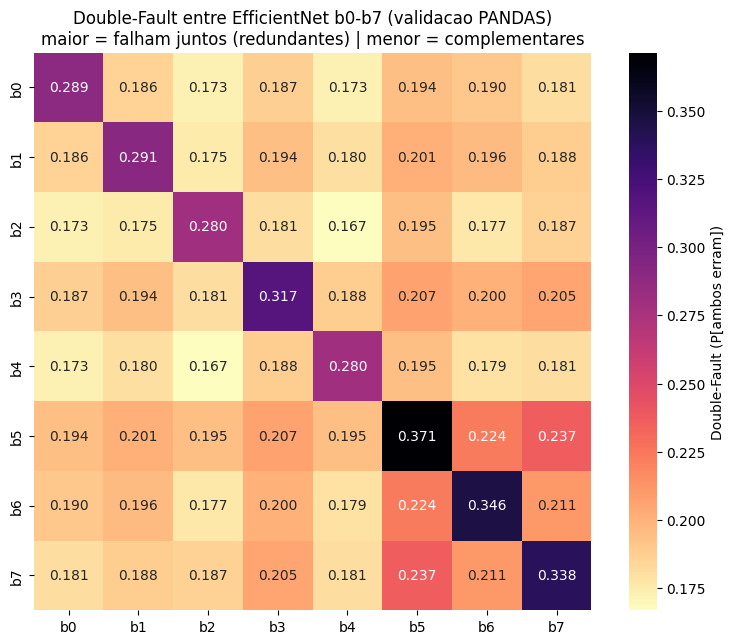

In [30]:
# DF_ij = (1/N) * sum_n [erro_i(n) AND erro_j(n)]
DF = (ERR @ ERR.T) / N        # (M, M), simetrica; diagonal = taxa de erro

df_matrix = pd.DataFrame(DF, index=MODELS_TO_RUN, columns=MODELS_TO_RUN)
df_matrix.to_csv(os.path.join(LOG_DIR, 'family-double-fault-matrix.csv'))
print('Matriz Double-Fault (linha/coluna = modelo):')
display(df_matrix.round(4))

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(df_matrix, annot=True, fmt='.3f', cmap='magma_r', square=True,
            cbar_kws={'label': 'Double-Fault (P[ambos erram])'}, ax=ax)
ax.set_title('Double-Fault entre EfficientNet b0-b7 (validacao PANDAS)\n'
             'maior = falham juntos (redundantes) | menor = complementares')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'family-double-fault-matrix.png'), dpi=200, bbox_inches='tight')
plt.show()

## 6. Projecao 2D dos modelos com t-SNE

Convertendo o double-fault (similaridade de co-falha) em **dissimilaridade**:

$$D_{ij} = \max_{a\neq b}(DF_{ab}) - DF_{ij} \quad (i\neq j), \qquad D_{ii}=0$$

Assim, modelos que **falham juntos** (DF alto) ficam **proximos** no mapa, e
modelos com comportamento de erro complementar ficam afastados. Como ha apenas 8
pontos, usamos `perplexity=3` e `metric='precomputed'`.


In [31]:
# matriz de dissimilaridade a partir do double-fault (off-diagonal), diagonal zerada
off = DF.copy()
np.fill_diagonal(off, np.nan)
dmax = np.nanmax(off)
D = dmax - DF
np.fill_diagonal(D, 0.0)
D = (D + D.T) / 2            # garante simetria numerica

tsne = TSNE(
    n_components=2,
    metric='precomputed',
    init='random',
    perplexity=3,
    learning_rate='auto',
    random_state=SEED,
)
emb = tsne.fit_transform(D)   # (M, 2)
print('Embedding t-SNE:\n', np.round(emb, 3))

Embedding t-SNE:
 [[  4.01  -73.677]
 [-65.     49.144]
 [-62.915 -31.822]
 [ 60.055  19.092]
 [ 50.753  91.037]
 [-14.647   2.264]
 [ -7.06   40.075]
 [ 19.848  -5.632]]


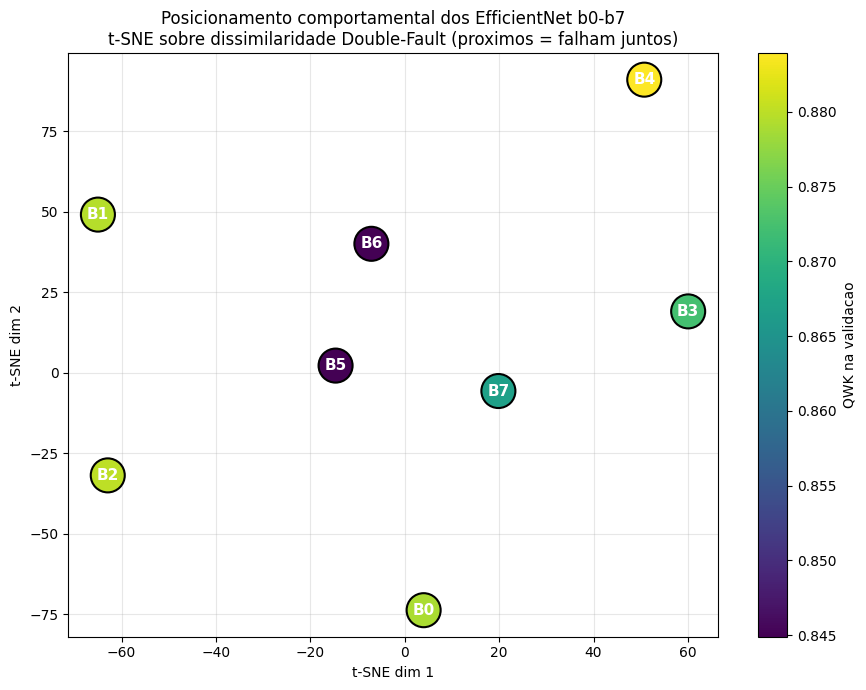

Artefatos salvos em logs/:
  - family-double-fault-predictions.csv
  - family-double-fault-matrix.csv / .png
  - family-double-fault-tsne.png


In [32]:
qwk_vals = perf['qwk'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(emb[:, 0], emb[:, 1], c=qwk_vals, s=600,
                cmap='viridis', edgecolors='black', linewidths=1.5, zorder=3)

for i, name in enumerate(MODELS_TO_RUN):
    ax.annotate(name.upper(), (emb[i, 0], emb[i, 1]),
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='white', zorder=4)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('QWK na validacao')

ax.set_title('Posicionamento comportamental dos EfficientNet b0-b7\n'
             't-SNE sobre dissimilaridade Double-Fault (proximos = falham juntos)')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'family-double-fault-tsne.png'), dpi=200, bbox_inches='tight')
plt.show()

print('Artefatos salvos em logs/:')
print('  - family-double-fault-predictions.csv')
print('  - family-double-fault-matrix.csv / .png')
print('  - family-double-fault-tsne.png')

## 7. Avaliacao individual no conjunto de TESTE (`data/test.csv`)

Aqui cada um dos 8 backbones (`b0`-`b7`) e avaliado no **conjunto de teste
independente** do PANDAS (`data/test.csv`), sem qualquer filtro de entropia
(o filtro de ruido so vale para treino/validacao). Para cada modelo guardamos as
**probabilidades ordinais por limiar** (`sigmoid(logits)`, shape `(N, 5)`), que
servem tanto para decodificar a predicao individual (`>0.5 -> soma -> ISUP 0..5`)
quanto para construir o ensemble por media de probabilidades (secao 8).

Metricas reportadas por modelo: **QWK** (kappa quadratico), **acuracia** e
**F1 macro**.

In [33]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# conjunto de teste independente — avaliado integralmente (sem filtro de entropia)
df_test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
df_test.columns = df_test.columns.str.strip()
df_test = drop_missing(df_test.reset_index(drop=True))

TEST_IMAGE_IDS = df_test['image_id'].str.strip().tolist()
gts_test = df_test['isup_grade'].to_numpy().astype(int)

print(f'Amostras de teste: {len(df_test)}')
print('Distribuicao por classe ISUP:')
print(df_test['isup_grade'].value_counts().sort_index())

Amostras de teste: 1590
Distribuicao por classe ISUP:
isup_grade
0    434
1    400
2    200
3    185
4    187
5    184
Name: count, dtype: int64


In [34]:
def make_loader(df, batch_size):
    ds = PandasOverlapDataset(IMAGES_DIR, df, transforms=None, overlap=0)
    return DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
    )


@torch.no_grad()
def predict_proba(model, name, df):
    """Retorna (probs, img_ids): probs = sigmoid(logits) com shape (N, OUTPUT_CLASSES)."""
    loader = make_loader(df, BATCH_SIZE[name])
    probs, img_ids = [], []
    for imgs, _, ids in tqdm(loader, desc=f'Test {name}', leave=False):
        imgs = imgs.to(device, non_blocking=True)
        with autocast(device_type='cuda', enabled=(USE_AMP and torch.cuda.is_available()),
                      dtype=torch.float16):
            logits = model(imgs)
        probs.append(torch.sigmoid(logits.float()).cpu())
        img_ids.extend([i.strip() for i in ids])
    return torch.cat(probs).numpy(), img_ids


def preds_from_proba(probs):
    """probs (N, 5) -> grau ISUP 0..5 (threshold @ 0.5, soma dos limiares)."""
    return (probs > 0.5).sum(axis=1).astype(int)

In [35]:
# inferencia de cada backbone no conjunto de teste (probabilidades ordinais)
proba_test = {}   # name -> probs (N, OUTPUT_CLASSES)
for name in MODELS_TO_RUN:
    print(f'>>> {name}')
    model = load_model(name)
    probs, ids = predict_proba(model, name, df_test)
    assert ids == TEST_IMAGE_IDS, f'desalinhamento de amostras de teste em {name}'
    proba_test[name] = probs
    free_vram(model)

print('\nInferencia de teste concluida para:', list(proba_test.keys()))

>>> b0


Test b0:   0%|          | 0/199 [00:00<?, ?it/s]

>>> b1


Test b1:   0%|          | 0/199 [00:00<?, ?it/s]

>>> b2


...

>>> b6


Test b6:   0%|          | 0/795 [00:00<?, ?it/s]

>>> b7


Test b7:   0%|          | 0/795 [00:00<?, ?it/s]


Inferencia de teste concluida para: ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7']


In [36]:
# metricas individuais no teste + tabela de predicoes
LABELS = [f'ISUP {i}' for i in range(6)]


def eval_preds(preds, gts):
    return dict(
        qwk=cohen_kappa_score(gts, preds, weights='quadratic'),
        accuracy=accuracy_score(gts, preds),
        macro_f1=f1_score(gts, preds, average='macro'),
    )


pred_test_matrix = {n: preds_from_proba(proba_test[n]) for n in MODELS_TO_RUN}

rows = []
for n in MODELS_TO_RUN:
    m = eval_preds(pred_test_matrix[n], gts_test)
    rows.append({'model': n.upper(), **m})
perf_test = pd.DataFrame(rows)

perf_test.to_csv(os.path.join(LOG_DIR, 'family-test-individual.csv'), index=False)
print('Salvo: logs/family-test-individual.csv')
display(perf_test.round(4))

# tabela de predicoes por amostra (uma coluna por modelo) + ground-truth
pred_test_df = pd.DataFrame({'image_id': TEST_IMAGE_IDS, 'isup_grade': gts_test})
for n in MODELS_TO_RUN:
    pred_test_df[n] = pred_test_matrix[n]
pred_test_df.to_csv(os.path.join(LOG_DIR, 'family-test-predictions.csv'), index=False)
print('Salvo: logs/family-test-predictions.csv')

Salvo: logs/family-test-individual.csv


,model,qwk,accuracy,macro_f1
0,B0,0.8736,0.7006,0.6596
1,B1,0.8757,0.7082,0.6578
2,B2,0.8749,0.7094,0.6635
3,B3,0.8459,0.6761,0.6286
4,B4,0.8677,0.7044,0.6558
5,B5,0.8318,0.6201,0.5455
6,B6,0.8371,0.6390,0.5693
7,B7,0.8511,0.6585,0.6029


Salvo: logs/family-test-predictions.csv


## 8. Estrategias de ensemble dos backbones selecionados

Combinamos os backbones em `ENSEMBLE_MEMBERS` com **varias estrategias** e
comparamos todas com os modelos individuais no conjunto de teste. As estrategias
operam sobre as probabilidades ordinais `sigmoid(logits)` (`proba_test`, shape
`(N, 5)`) ou sobre as predicoes ja decodificadas (`pred_test_matrix`, ISUP 0..5):

**Soft (combinam probabilidades, depois decodificam `>0.5 -> soma`)**
- **mean** — media simples das probabilidades por limiar.
- **weighted_mean** — media ponderada pelo **QWK de validacao** de cada membro
  (pesos normalizados; sem usar o teste, evitando vazamento).
- **max** — maximo elemento-a-elemento das probabilidades.

**Hard (combinam predicoes ISUP discretas)**
- **majority_vote** — classe mais votada; empate desfeito pela **mediana** dos
  votos (coerente com a ordem ISUP).
- **weighted_vote** — voto majoritario ponderado pelo QWK de validacao.
- **median** — mediana das predicoes dos membros (robusta e ordinal).

**Meta-aprendizes (treinados na VALIDACAO, aplicados ao teste)**
- **boosting** — `GradientBoostingClassifier` (boosting de arvores) treinado
  sobre as probabilidades concatenadas dos membros como features (stacking com
  meta-modelo de boosting).
- **stacking_lr** — meta-modelo de **regressao logistica** sobre as mesmas
  features (stacking linear classico).

Para cada estrategia reportamos **QWK**, **acuracia** e **F1 macro**.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

ENSEMBLE_MEMBERS = ['b0', 'b1', "b2", 'b3', 'b4']
# ENSEMBLE_MEMBERS = ['b0', 'b1', "b2", 'b3', 'b4', 'b5', 'b6', 'b7']
ENS_TAG = '+'.join(ENSEMBLE_MEMBERS)

# pesos por desempenho na VALIDACAO (QWK normalizado) — nao usa o teste
val_qwk = perf.set_index('model').loc[ENSEMBLE_MEMBERS, 'qwk'].to_numpy()
WEIGHTS = val_qwk / val_qwk.sum()

P_test  = np.stack([proba_test[n] for n in ENSEMBLE_MEMBERS])         # (M, N, 5)
PRED_M  = np.vstack([pred_test_matrix[n] for n in ENSEMBLE_MEMBERS])  # (M, N) ISUP 0..5

# features de stacking: probabilidades concatenadas dos membros
X_val  = np.hstack([proba_val[n]  for n in ENSEMBLE_MEMBERS])         # (Nval,  M*5)
X_test = np.hstack([proba_test[n] for n in ENSEMBLE_MEMBERS])         # (Ntest, M*5)


def _vote(votes, w=None):
    """Voto (ponderado) por amostra; empate desfeito pela mediana dos votos."""
    M, N = votes.shape
    w = np.ones(M) if w is None else np.asarray(w)
    out = np.empty(N, dtype=int)
    for i in range(N):
        col = votes[:, i]
        tally = np.bincount(col, weights=w, minlength=6)
        top = tally.max()
        winners = np.where(np.isclose(tally, top))[0]
        out[i] = winners[0] if len(winners) == 1 else int(np.round(np.median(col)))
    return out


def _gb():
    clf = GradientBoostingClassifier(random_state=SEED)
    clf.fit(X_val, gts)                       # gts = ground-truth da VALIDACAO
    return clf.predict(X_test).astype(int)


def _lr():
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_val, gts)
    return clf.predict(X_test).astype(int)


STRATEGIES = {
    'mean':          lambda: preds_from_proba(P_test.mean(axis=0)),
    'weighted_mean': lambda: preds_from_proba(np.tensordot(WEIGHTS, P_test, axes=(0, 0))),
    'max':           lambda: preds_from_proba(P_test.max(axis=0)),
    'majority_vote': lambda: _vote(PRED_M),
    'weighted_vote': lambda: _vote(PRED_M, WEIGHTS),
    'median':        lambda: np.round(np.median(PRED_M, axis=0)).astype(int),
    'boosting':      _gb,
    'stacking_lr':   _lr,
}

print(f'Membros: {ENS_TAG}   pesos(QWK val) = '
      + ', '.join(f'{n}:{w:.3f}' for n, w in zip(ENSEMBLE_MEMBERS, WEIGHTS)) + '\n')

ens_results = {}
for sname, fn in STRATEGIES.items():
    preds = fn()
    ens_results[sname] = {'preds': preds, 'metrics': eval_preds(preds, gts_test)}
    m = ens_results[sname]['metrics']
    print(f"  {sname:14s}  QWK={m['qwk']:.4f}  Acc={m['accuracy']*100:5.2f}%  F1={m['macro_f1']:.4f}")

# tabela comparativa: 8 individuais + todas as estrategias de ensemble
comp = perf_test.copy()
ens_rows = pd.DataFrame([
    {'model': f'ENS-{s}({ENS_TAG})', **ens_results[s]['metrics']} for s in STRATEGIES
])
comp = pd.concat([comp, ens_rows], ignore_index=True)
comp.to_csv(os.path.join(LOG_DIR, 'family-test-ensemble-comparison.csv'), index=False)
display(comp.round(4))

Membros: b0+b1+b2+b3+b4+b5+b6+b7   pesos(QWK val) = b0:0.126, b1:0.127, b2:0.127, b3:0.125, b4:0.127, b5:0.122, b6:0.122, b7:0.125

  mean            QWK=0.8866  Acc=73.96%  F1=0.6952
  weighted_mean   QWK=0.8865  Acc=73.90%  F1=0.6943
  max             QWK=0.8067  Acc=54.09%  F1=0.4947
  majority_vote   QWK=0.8816  Acc=74.28%  F1=0.7009
  weighted_vote   QWK=0.8828  Acc=74.84%  F1=0.7063
  median          QWK=0.8877  Acc=73.46%  F1=0.6905
  boosting        QWK=0.8743  Acc=73.58%  F1=0.6910
  stacking_lr     QWK=0.8897  Acc=75.53%  F1=0.7138


,model,qwk,accuracy,macro_f1
0,B0,0.8736,0.7006,0.6596
1,B1,0.8757,0.7082,0.6578
2,B2,0.8749,0.7094,0.6635
3,B3,0.8459,0.6761,0.6286
4,B4,0.8677,0.7044,0.6558
5,B5,0.8318,0.6201,0.5455
6,B6,0.8371,0.6390,0.5693
7,B7,0.8511,0.6585,0.6029
8,ENS-mean(b0+b1+b2+b3+b4+b5+b6+b7),0.8866,0.7396,0.6952
9,ENS-weighted_mean(b0+b1+b2+b3+b4+b5+b6+b7),0.8865,0.7390,0.6943


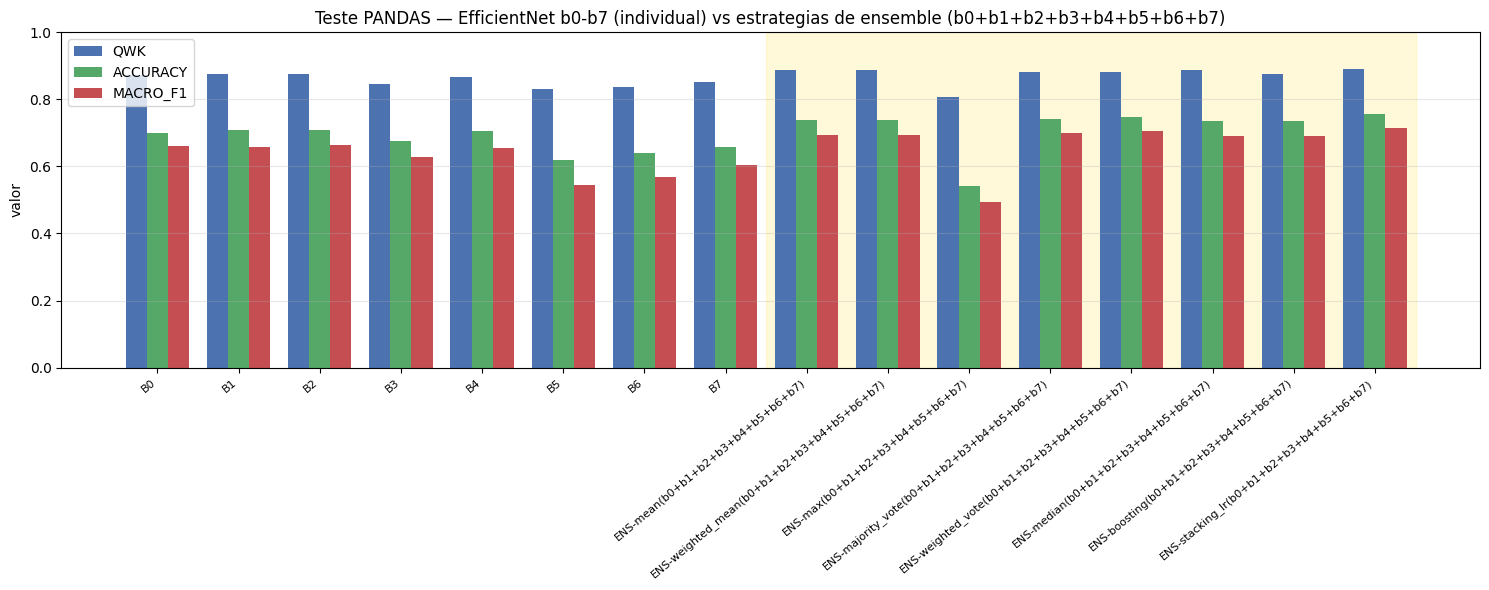

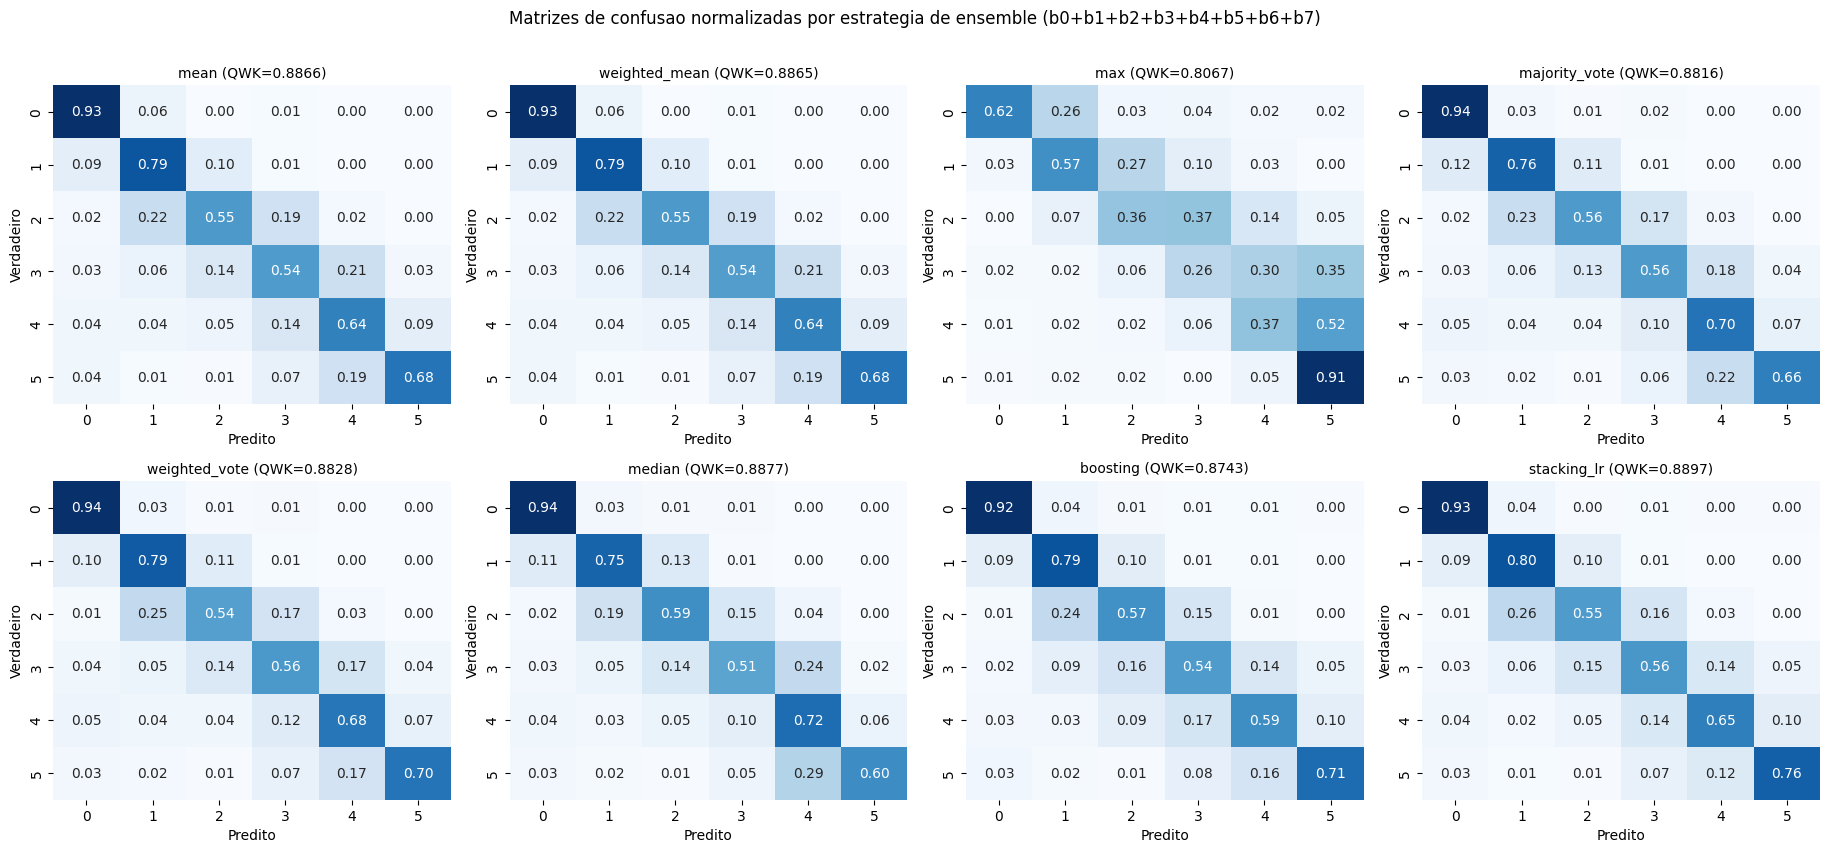

In [52]:
# (a) comparacao de QWK/Acc/F1: 8 individuais + todas as estrategias de ensemble
metrics_cols = ['qwk', 'accuracy', 'macro_f1']
x = np.arange(len(comp))
width = 0.26
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(15, 6))
for k, (col, c) in enumerate(zip(metrics_cols, colors)):
    ax.bar(x + (k - 1) * width, comp[col], width, label=col.upper(), color=c)
ax.set_xticks(x)
ax.set_xticklabels(comp['model'], rotation=40, ha='right', fontsize=8)
ax.set_ylim(0, 1.0)
ax.set_ylabel('valor')
ax.set_title(f'Teste PANDAS — EfficientNet b0-b7 (individual) vs estrategias de ensemble ({ENS_TAG})')
# destaca o bloco das estrategias de ensemble
ax.axvspan(len(perf_test) - 0.5, x[-1] + 0.5, color='gold', alpha=0.15, zorder=0)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'family-test-comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

# (b) matrizes de confusao normalizadas — uma por estrategia de ensemble
strats = list(STRATEGIES)
ncols  = 4
nrows  = int(np.ceil(len(strats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax_, strat in zip(axes, strats):
    preds = ens_results[strat]['preds']
    cm = confusion_matrix(gts_test, preds, labels=list(range(6)))
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=range(6), yticklabels=range(6), ax=ax_)
    qwk = ens_results[strat]['metrics']['qwk']
    ax_.set_title(f'{strat} (QWK={qwk:.4f})', fontsize=10)
    ax_.set_ylabel('Verdadeiro'); ax_.set_xlabel('Predito')
for ax_ in axes[len(strats):]:
    ax_.axis('off')
fig.suptitle(f'Matrizes de confusao normalizadas por estrategia de ensemble ({ENS_TAG})', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'family-test-ensemble-confusion.png'), dpi=200, bbox_inches='tight')
plt.show()

In [53]:
# melhor estrategia por QWK + relatorios + dump dos artefatos de teste
best = max(STRATEGIES, key=lambda s: ens_results[s]['metrics']['qwk'])
print(f'>> Melhor estrategia (QWK): {best}\n')

reports = {
    s: classification_report(gts_test, ens_results[s]['preds'], labels=list(range(6)),
                             target_names=LABELS, digits=4, zero_division=0)
    for s in STRATEGIES
}
print(f'== Ensemble {best} ({ENS_TAG}) ==')
print(reports[best])

res_path = os.path.join(LOG_DIR, 'family-test-results.txt')
with open(res_path, 'w') as f:
    f.write('Avaliacao no conjunto de TESTE do PANDAS (data/test.csv)\n')
    f.write(f'N amostras = {len(df_test)}   membros = {ENS_TAG}\n\n')
    f.write('== Desempenho individual ==\n')
    f.write(perf_test.round(4).to_string(index=False) + '\n\n')
    f.write('== Estrategias de ensemble (resumo) ==\n')
    f.write(comp[comp['model'].str.startswith('ENS-')].round(4).to_string(index=False) + '\n\n')
    f.write(f'Melhor estrategia por QWK: {best}\n\n')
    for s in STRATEGIES:
        m = ens_results[s]['metrics']
        f.write(f'== {s} ==\n')
        f.write(f"QWK={m['qwk']:.4f}  Acc={m['accuracy']*100:.2f}%  MacroF1={m['macro_f1']:.4f}\n")
        f.write(reports[s] + '\n')

# predicoes de todas as estrategias por amostra
for s in STRATEGIES:
    pred_test_df[f'ens_{s}'] = ens_results[s]['preds']
pred_test_df.to_csv(os.path.join(LOG_DIR, 'family-test-predictions.csv'), index=False)

print('\nArtefatos de teste salvos em logs/:')
print('  - family-test-individual.csv')
print('  - family-test-predictions.csv')
print('  - family-test-ensemble-comparison.csv')
print('  - family-test-comparison.png')
print('  - family-test-ensemble-confusion.png')
print('  - family-test-results.txt')

>> Melhor estrategia (QWK): stacking_lr

== Ensemble stacking_lr (b0+b1+b2+b3+b4+b5+b6+b7) ==
              precision    recall  f1-score   support

      ISUP 0     0.8766    0.9332    0.9040       434
      ISUP 1     0.7848    0.8025    0.7936       400
      ISUP 2     0.5829    0.5450    0.5633       200
      ISUP 3     0.5714    0.5622    0.5668       185
      ISUP 4     0.6816    0.6524    0.6667       187
      ISUP 5     0.8187    0.7609    0.7887       184

    accuracy                         0.7553      1590
   macro avg     0.7193    0.7094    0.7138      1590
weighted avg     0.7514    0.7553    0.7529      1590


Artefatos de teste salvos em logs/:
  - family-test-individual.csv
  - family-test-predictions.csv
  - family-test-ensemble-comparison.csv
  - family-test-comparison.png
  - family-test-ensemble-confusion.png
  - family-test-results.txt
